In [ ]:
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pylab as plt
from matplotlib.pylab import rcParams


Notes on process:

- I'm clustering only weather variables and all of them, i.e. for wind and sun conditions. 
    - Weather is the factor determining your grouping and power is the output of whatever that grouping ends up looking like. 
    - Each cluster is a different weather scenario => having all weather conditions together as input enables you to cover all the spectrum of possibilities.
- The variables that you include in the weather-defining factors are important and not all need be there. I'll progressively decide on whoch ones to incorporate

In [ ]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

final_file = "data/complete_dataframe_30min.csv"
df = pd.read_csv(str(ROOT/final_file), delimiter=',', decimal='.', parse_dates=['ts'], index_col='ts') #ts is already the index :)

In [ ]:
# Column names for reference
df.columns

In [ ]:
def reshape_to_daily(df):
    df = df.copy()
    # Extract date and time
    df["date"] = df.index.date
    df["time"] = df.index.strftime("%H:%M")
    # Melt to long format (all value columns)
    value_cols = [c for c in df.columns if c not in ["date", "time"]]
    df_long = df.melt(
        id_vars=["date", "time"],
        value_vars=value_cols,
        var_name="variable",
        value_name="value"
    )

    # Create combined column names: wind_speed_08:00 etc.
    df_long["col_name"] = df_long["variable"] + "_" + df_long["time"]

    # Pivot to wide format
    df_wide = df_long.pivot(
        index="date",
        columns="col_name",
        values="value"
    )

    # Optional: sort columns
    df_wide = df_wide.sort_index(axis=1)
    df_wide.index.name = "date"

    return df_wide[1:] # REMOVES THE FIRST DAY TO AVOID NANs

### SUGGESTION FOR HOW TO IMPLEMENT reshape_to_daily:

In [ ]:
def evaluate_kmeans_for_k(train_df, test_df, feature_cols, k, random_state=42):
    """
    Train/evaluate one KMeans model for one value of K.
    """
    feature_cols_day = []    
    times = pd.date_range("00:00", "23:30", freq="30min").strftime("%H:%M").tolist()
    for feature in feature_cols:
        for time in times: 
            feature_cols_day.append(f"{feature}_{time}")
    ########### makes feature_ cols looks like: 'radia_glob_00:00', 'radia_glob_00:30'.... ########
    aggrigated_power_columns = ['PV_total', 'WT_total', 'Power_total']
    power_columns = []
    for col in aggrigated_power_columns:
        for time in times: 
            power_columns.append(f"{col}_{time}")
    print(power_columns)
    ######## makes the power cols look like: ['PV_total_00:00', 'PV_total_00:30', 'PV_total_01:00', 'PV_total_01:30' ... ##### 

    train_df_day = reshape_to_daily(train_df)
    test_df_day = reshape_to_daily(test_df)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df_day[feature_cols_day]) ### THESE I CHANGED TOO 
    X_test = scaler.transform(test_df_day[feature_cols_day])### THESE I CHANGED TOO 

    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )

    train_clusters = kmeans.fit_predict(X_train)
    test_clusters = kmeans.predict(X_test)

    train_labeled = train_df_day.copy()
    test_labeled = test_df_day.copy()

    train_labeled['cluster'] = train_clusters
    test_labeled['cluster'] = test_clusters

    # Learn average power from TRAIN only
    cluster_power = train_labeled.groupby('cluster')[power_columns].mean() #### HERE I INSERT POWER_COLUMNS #############



    # Predict TEST by cluster lookup
    for target in power_columns:
        test_labeled[f'{target}_pred'] = test_labeled['cluster'].map(cluster_power[target])

    # Cluster size diagnostics
    cluster_sizes = pd.Series(train_clusters).value_counts()
    train_size = len(train_df_day)

    min_cluster_size = cluster_sizes.min()
    max_cluster_size = cluster_sizes.max()

    min_cluster_pct = (min_cluster_size / train_size) * 100
    max_cluster_pct = (max_cluster_size / train_size) * 100

    metrics = {
        'K': k,
        'train_inertia': kmeans.inertia_,
        'train_silhouette': np.nan,
        'test_mae_pv': mean_absolute_error(test_labeled['PV_total'], test_labeled['PV_total_pred']),
        'test_rmse_pv': safe_rmse(test_labeled['PV_total'], test_labeled['PV_total_pred']),
        'test_mae_wt': mean_absolute_error(test_labeled['WT_total'], test_labeled['WT_total_pred']),
        'test_rmse_wt': safe_rmse(test_labeled['WT_total'], test_labeled['WT_total_pred']),
        'test_mae_total': mean_absolute_error(test_labeled['Power_total'], test_labeled['Power_total_pred']),
        'test_rmse_total': safe_rmse(test_labeled['Power_total'], test_labeled['Power_total_pred']),
        'min_train_cluster_size': min_cluster_size,
        'max_train_cluster_size': max_cluster_size,
        'min_cluster_pct': min_cluster_pct,
        'max_cluster_pct': max_cluster_pct,
    }

    unique_clusters = np.unique(train_clusters)
    if len(unique_clusters) > 1 and len(train_labeled) > len(unique_clusters):
        metrics['train_silhouette'] = silhouette_score(X_train, train_clusters)

    return metrics, train_labeled, test_labeled, cluster_power, scaler, kmeans


In [ ]:
# ============================================================
# 1. USER SETTINGS
# ============================================================
# Resampling and Using Wind Direction as Weather Parameter

# Name of timestamp column
timestamp_col = 'ts'   

# Whether to resample
do_resample = False

# Resample as '15min', '30min', '1H', '3H', '1D', where rule = ''

# Optional: include wind direction properly encoded
use_wind_direction = False
wind_dir_col = 'wind_dir'

# Weather features to use for clustering
weather_cols = ['radia_glob','wind_speed','temp_dry','wind_max']

# PV columns to aggregate
pv_cols = ['B117_m','B319_m','B330_1_m','B330_2_m','B330_3_m','B716_m','B715_m']

# Wind power columns to aggregate
wind_power_cols = [
    'Aircon_WT Power_m',
    'Gaia_WT Power_m',
]

# Multi-fold settings => 
block_size = 48 * 7        # split full time series into 7-day time blocks
min_train_blocks = 2      # first folds need at least this many train blocks

# Range of K values to test
k_values = range(2, 25)

# Random seed
random_state = 42

# Interval in hours of the OG power output 
interval_hours = 0.5 # 30 mins resolution

In [ ]:
# 2. HELPER FUNCTIONS
wind_power_cols = ['Aircon_WT Power_m','Gaia_WT Power_m']

def add_wind_direction_encoding(df, wind_dir_col):
    """
    Encode wind direction as sin/cos to handle circularity.
    """
    df = df.copy()
    radians = np.deg2rad(df[wind_dir_col])
    df['wind_dir_sin'] = np.sin(radians)
    df['wind_dir_cos'] = np.cos(radians)
    return df


def resample_dataframe(df, timestamp_col, rule='1H', agg='mean'):
    """
    Resample dataframe by time.
    Timestamp is datetime index of df.
    Only numeric columns are retained by the aggregation.
    """
    df_resampled = df.copy()
    df_resampled.index = pd.to_datetime(df_resampled.index)

    if agg == 'mean':
        df_resampled = df_resampled.resample(rule).mean()
    elif agg == 'sum':
        df_resampled = df_resampled.resample(rule).sum()
    elif agg == 'median':
        df_resampled = df_resampled.resample(rule).median()
    else:
        raise ValueError("agg must be one of: 'mean', 'sum', 'median'")

    return df_resampled

def prepare_dataframe(df):
    """
    Prepare a modeling dataframe:
    - optionally encode wind direction
    - create aggregated power columns
    - remove rows with missing required data
    """
    df_model = df.copy()

    # Aggregate plant outputs
    df_model['PV_total'] = df_model[pv_cols].sum(axis=1, min_count=1)
    df_model['WT_total'] = df_model[wind_power_cols].sum(axis=1, min_count=1)
    df_model['Power_total'] = df_model[['PV_total', 'WT_total']].sum(axis=1, min_count=1)

    feature_cols = weather_cols.copy()

    if use_wind_direction:
        df_model = add_wind_direction_encoding(df_model, wind_dir_col)
        feature_cols.extend(['wind_dir_sin', 'wind_dir_cos'])

    required_cols = feature_cols + ['PV_total', 'WT_total', 'Power_total']
    df_model = df_model.dropna(subset=required_cols).copy()

    return df_model, feature_cols


### Making cluster models with different k's to compare performance -- (train & test separation is present)

In [ ]:
def safe_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_kmeans_for_k(train_df, test_df, feature_cols, k, random_state):
    """
    Train/evaluate one KMeans model for one value of K.
    """
    #Transform the data in each column into relative values within their category to 
    #not have the different magnitudes of quantities affect the distance used to determine the centroid
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feature_cols]) #make it save mean and std and apply for all data pts
    X_test = scaler.transform(test_df[feature_cols])

    #Define k-means algorithm in terms of the number of clusters to be created, a.k.a. centroids to be had
    # n_init says the number of times the algorithm is ran; the one with the lowest inertia is kept
    kmeans = KMeans(n_clusters=k, random_state = random_state, n_init=10)

    train_clusters = kmeans.fit_predict(X_train)
    test_clusters = kmeans.predict(X_test)

    train_labeled = train_df.copy()
    test_labeled = test_df.copy()

    train_labeled['cluster'] = train_clusters
    test_labeled['cluster'] = test_clusters

    # Learn average power from TRAIN only
    cluster_power = train_labeled.groupby('cluster')[['PV_total', 'WT_total', 'Power_total']].mean()

    # Predict TEST by cluster lookup
    for target in ['PV_total', 'WT_total', 'Power_total']:
        test_labeled[f'{target}_pred'] = test_labeled['cluster'].map(cluster_power[target])

    # Cluster size diagnostics
    cluster_sizes = pd.Series(train_clusters).value_counts()
    train_size = len(train_df)

    min_cluster_size = cluster_sizes.min()
    max_cluster_size = cluster_sizes.max()
        #min_cluster_pct = (min_cluster_size / train_size) * 100
        #max_cluster_pct = (max_cluster_size / train_size) * 100

    metrics = {
        'K': k,
        'train_inertia': kmeans.inertia_,
        'train_silhouette': np.nan,
        'test_mae_pv': mean_absolute_error(test_labeled['PV_total'], test_labeled['PV_total_pred']),
        'test_rmse_pv': safe_rmse(test_labeled['PV_total'], test_labeled['PV_total_pred']),
        'test_mae_wt': mean_absolute_error(test_labeled['WT_total'], test_labeled['WT_total_pred']),
        'test_rmse_wt': safe_rmse(test_labeled['WT_total'], test_labeled['WT_total_pred']),
        'test_mae_total': mean_absolute_error(test_labeled['Power_total'], test_labeled['Power_total_pred']),
        'test_rmse_total': safe_rmse(test_labeled['Power_total'], test_labeled['Power_total_pred']),
        'min_train_cluster_size': min_cluster_size,
        'max_train_cluster_size': max_cluster_size,
        #'min_cluster_pct': min_cluster_pct,
        #'max_cluster_pct': max_cluster_pct,
    }

    unique_clusters = np.unique(train_clusters)
    if len(unique_clusters) > 1 and len(train_labeled) > len(unique_clusters):
        metrics['train_silhouette'] = silhouette_score(X_train, train_clusters)

    return metrics, train_labeled, test_labeled, cluster_power, scaler, kmeans

def plot_k_comparison(results_df, min_cluster_pct_threshold=3.0):
    """
    Plot K vs mean test MAE, mean silhouette, and worst-case minimum cluster percentage.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Primary axis: MAE
    line1 = ax1.plot(
        results_df['K'],
        results_df['mean_test_mae_total'],
        marker='o',
        linestyle='-',
        linewidth=2,
        label='Mean Test MAE (Total Power)'
    )
    ax1.set_xlabel('Number of clusters (K)')
    ax1.set_ylabel('Mean Test MAE (Total Power)')
    ax1.tick_params(axis='y')

    # Secondary axis: silhouette + cluster %
    ax2 = ax1.twinx()

    #line2 = ax2.plot(
     #   results_df['K'],
     #   results_df['mean_train_silhouette'],
     #   marker='s',
     #   linestyle='--',
     #   linewidth=2,
     #   label='Mean Train Silhouette')

    line3 = ax2.plot(
        results_df['K'],
        results_df['min_of_min_cluster_pct'],
        marker='^',
        linestyle=':',
        linewidth=2,
        label='Worst-case min cluster %'
    )

    ax2.axhline(
        min_cluster_pct_threshold,
        linestyle='-.',
        linewidth=1.5,
        label=f'Min cluster threshold ({min_cluster_pct_threshold:.1f}%)'
    )

    ax2.set_ylabel('Cluster %')
    ax2.tick_params(axis='y')

    # Best K by MAE
    best_k = results_df.loc[results_df['mean_test_mae_total'].idxmin(), 'K']
    ax1.axvline(best_k, linestyle=':', linewidth=1)
    ax1.text(best_k, ax1.get_ylim()[1], f'  best K={best_k}', verticalalignment='top')

    # Combined legend
    lines = line1 + line3
    labels = [l.get_label() for l in lines]
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(lines + handles2[-1:], labels + labels2[-1:], loc='upper right', )

    ax1.set_title('K comparison: error, cluster quality, and minimum cluster size')
    plt.tight_layout()
    plt.show()

In [ ]:
def make_monthly_folds_with_sampled_test_days(df,n_test_days_per_month,random_state):
    """
    Create folds by month.
    For each month:
      - test = a small number of full sampled days from that month
      - train = all remaining rows from the full dataset
    Assumes df has a DatetimeIndex.
    Returns:
      folds: list of (train_idx, test_idx)
      month_info: list of metadata dictionaries for inspection
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df must have a DatetimeIndex")

    rng = np.random.default_rng(random_state) #keeping consistent seed for random generations 

    # Reset index so we can return integer row indices compatible with iloc
    temp = df.copy().reset_index()
    time_col = temp.columns[0]

    temp['year_month'] = temp[time_col].dt.to_period('M') #yyyy-mm label for data
    temp['date_only'] = temp[time_col].dt.floor('D') #yyyy-mm-dd label for data

    folds = []
    month_info = []

    for ym, month_df in temp.groupby('year_month'):
        unique_days = np.array(sorted(month_df['date_only'].unique())) #remove duplicate 'date_only' stamps
        if len(unique_days) == 0: #have you picked out any days for that month? No? Continue
            continue

        n_pick = min(n_test_days_per_month, len(unique_days)) #set num of days to be picked out as smallest of two options
        test_days = rng.choice(unique_days, size=n_pick, replace=False)

        month_mask = temp['year_month'] == ym
        test_mask = temp['date_only'].isin(test_days)

        # test rows: only the sampled days from this month
        test_idx = temp.index[month_mask & test_mask].to_numpy()

        # train rows: everything else
        train_idx = temp.index[~temp.index.isin(test_idx)].to_numpy()

        folds.append((train_idx, test_idx))
        month_info.append({
            'year_month': str(ym),
            'n_days_in_month': len(unique_days), #num of days in month to pick from 
            'n_test_days': n_pick, #num of randomly chosen days making up the test for that month
            'test_days': sorted(pd.to_datetime(test_days).astype(str)),
            'train_rows': len(train_idx),
            'test_rows': len(test_idx),
        })

    return folds, month_info

def evaluate_kmeans_across_folds(df_model, feature_cols, k, folds, random_state):
    """
    Evaluate one K across multiple time folds and average the results.
    """
    fold_metrics = []
    fold_models = []

    for fold_num, (train_idx, test_idx) in enumerate(folds, start=1):
        train_df = df_model.iloc[train_idx].copy()
        test_df = df_model.iloc[test_idx].copy()

        metrics, train_labeled, test_labeled, cluster_power, scaler, kmeans = evaluate_kmeans_for_k(
            train_df, test_df,feature_cols,k,random_state=random_state)

        metrics['fold'] = fold_num
        metrics['# train_rows'] = len(train_df)
        metrics['# test_rows'] = len(test_df)

        fold_metrics.append(metrics)
        fold_models.append({'fold': fold_num,
            'train_labeled': train_labeled,
            'test_labeled': test_labeled,
            'cluster_power': cluster_power,
            'scaler': scaler,
            'kmeans': kmeans,
        })

    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary = {
        'K': k,
        'mean_train_inertia': fold_metrics_df['train_inertia'].mean(),
        'mean_train_silhouette': fold_metrics_df['train_silhouette'].mean(),
        'mean_test_mae_pv': fold_metrics_df['test_mae_pv'].mean(),
        'mean_test_rmse_pv': fold_metrics_df['test_rmse_pv'].mean(),
        'mean_test_mae_wt': fold_metrics_df['test_mae_wt'].mean(),
        'mean_test_rmse_wt': fold_metrics_df['test_rmse_wt'].mean(),
        'mean_test_mae_total': fold_metrics_df['test_mae_total'].mean(),
        'mean_test_rmse_total': fold_metrics_df['test_rmse_total'].mean(),
        'mean_min_train_cluster_size': fold_metrics_df['min_train_cluster_size'].mean(),
        'mean_max_train_cluster_size': fold_metrics_df['max_train_cluster_size'].mean(),
        'mean_min_cluster_pct': fold_metrics_df['min_cluster_pct'].mean(),
        'min_of_min_cluster_pct': fold_metrics_df['min_cluster_pct'].min(),
        'mean_max_cluster_pct': fold_metrics_df['max_cluster_pct'].mean(),
        'std_test_mae_total': fold_metrics_df['test_mae_total'].std(),
        'n_folds': len(fold_metrics_df),
    }

    return summary, fold_metrics_df, fold_models


def fit_final_kmeans_on_all_data(df_model, feature_cols, k, random_state=42):
    """
    Fit final descriptive model on all available data after best K is selected.
    This is for cluster descriptions / scenario interpretation, not unbiased testing.
    """
    scaler = StandardScaler()
    X_all = scaler.fit_transform(df_model[feature_cols])

    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )

    all_clusters = kmeans.fit_predict(X_all)

    all_labeled = df_model.copy()
    all_labeled['cluster'] = all_clusters

    cluster_power = all_labeled.groupby('cluster')[['PV_total', 'WT_total', 'Power_total']].mean()

    return all_labeled, cluster_power, scaler, kmeans

def predict_power_for_new_weather(new_weather_df, feature_cols, scaler, kmeans, cluster_power):
    """
    Predict power for new weather scenarios.
    """
    X_new = scaler.transform(new_weather_df[feature_cols])
    new_clusters = kmeans.predict(X_new)

    pred_df = new_weather_df.copy()
    pred_df['cluster'] = new_clusters
    pred_df['PV_total_pred'] = pd.Series(new_clusters).map(cluster_power['PV_total']).values
    pred_df['WT_total_pred'] = pd.Series(new_clusters).map(cluster_power['WT_total']).values
    pred_df['Power_total_pred'] = pd.Series(new_clusters).map(cluster_power['Power_total']).values

    return pred_df

def compute_cluster_error_stats(test_labeled):
    """
    Compute per-cluster error statistics on the TEST set.
    Assumes test_labeled contains:
      - cluster
      - actual columns: PV_total, WT_total, Power_total
      - prediction columns: PV_total_pred, WT_total_pred, Power_total_pred
    """
    df_err = test_labeled.copy()

    # Absolute errors
    df_err['PV_abs_error'] = (df_err['PV_total'] - df_err['PV_total_pred']).abs()
    df_err['WT_abs_error'] = (df_err['WT_total'] - df_err['WT_total_pred']).abs()
    df_err['Power_abs_error'] = (df_err['Power_total'] - df_err['Power_total_pred']).abs()

    cluster_stats = df_err.groupby('cluster').agg(
        test_count=('cluster', 'size'),
        pv_mae=('PV_abs_error', 'mean'),
        wt_mae=('WT_abs_error', 'mean'),
        power_mae=('Power_abs_error', 'mean'),
        pv_actual_mean=('PV_total', 'mean'),
        pv_pred_mean=('PV_total_pred', 'mean'),
        wt_actual_mean=('WT_total', 'mean'),
        wt_pred_mean=('WT_total_pred', 'mean'),
        power_actual_mean=('Power_total', 'mean'),
        power_pred_mean=('Power_total_pred', 'mean'),
    ).reset_index()

    return cluster_stats

def plot_cluster_mae_with_counts(cluster_stats, sort_by='power_mae'):
    """
    Plot per-cluster MAE with test sample counts overlaid.
    """
    plot_df = cluster_stats.sort_values(sort_by).copy()

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # --- Bar plot (MAE) ---
    bars = ax1.bar(
        plot_df['cluster'].astype(str),
        plot_df['power_mae'],
        label='MAE (Total Power)'
    )

    ax1.set_xlabel('Cluster')
    ax1.set_ylabel('MAE (Total Power)')
    ax1.set_title('Per-cluster MAE and test sample count for best K')

    # --- Line plot (counts) ---
    ax2 = ax1.twinx()
    line = ax2.plot(
        plot_df['cluster'].astype(str),
        plot_df['test_count'],
        marker='o',
        linestyle='--',
        linewidth=2,
        color='pink',
        label='Test sample count'
    )

    ax2.set_ylabel('Test sample count')

    # --- Combine legends ---
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(handles1 + handles2, labels1 + labels2, loc='best')

    plt.tight_layout()
    plt.show()

def build_cluster_descriptions(train_labeled, feature_cols):
    """
    Build a per-cluster summary from TRAIN data so every learned cluster
    gets a description, even if it does not appear in the TEST set.
    """
    cluster_desc = train_labeled.groupby('cluster').agg(
        cluster_size=('cluster', 'size'),
        **{col: (col, 'mean') for col in feature_cols}
    ).reset_index()

    return cluster_desc

def add_full_dataframe_predictions(df_model, feature_cols, scaler, kmeans, cluster_power):
    """
    Add cluster assignments and predicted power columns to the full dataframe.
    """
    X_all = scaler.transform(df_model[feature_cols])
    all_clusters = kmeans.predict(X_all)

    df_pred = df_model.copy()
    df_pred['cluster'] = all_clusters

    cluster_series = pd.Series(all_clusters, index=df_pred.index)

    df_pred['PV_total_pred'] = cluster_series.map(cluster_power['PV_total'])
    df_pred['WT_total_pred'] = cluster_series.map(cluster_power['WT_total'])
    df_pred['Power_total_pred'] = cluster_series.map(cluster_power['Power_total'])

    return df_pred


def aggregate_to_daily_energy(df, interval_hours=0.5):
    """
    Aggregate 30-minute power data (kW) into daily energy (kWh).
    Works for actual and predicted columns if present.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DatetimeIndex")

    cols = [
        'PV_total', 'WT_total', 'Power_total',
        'PV_total_pred', 'WT_total_pred', 'Power_total_pred'
    ]
    available_cols = [c for c in cols if c in df.columns]

    daily = df[available_cols].resample('1D').sum() * interval_hours

    rename_map = {
        'PV_total': 'PV_energy_kWh',
        'WT_total': 'WT_energy_kWh',
        'Power_total': 'Total_energy_kWh',
        'PV_total_pred': 'PV_energy_pred_kWh',
        'WT_total_pred': 'WT_energy_pred_kWh',
        'Power_total_pred': 'Total_energy_pred_kWh',
    }

    daily = daily.rename(columns={k: v for k, v in rename_map.items() if k in daily.columns})
    return daily


def plot_daily_total_energy(df_daily):
    plt.figure(figsize=(10, 5))

    if 'Total_energy_kWh' in df_daily.columns:
        plt.plot(df_daily.index, df_daily['Total_energy_kWh'], label='Actual daily total energy')
    if 'Total_energy_pred_kWh' in df_daily.columns:
        plt.plot(df_daily.index, df_daily['Total_energy_pred_kWh'], label='Predicted daily total energy')

    plt.xlabel('Date')
    plt.ylabel('Daily total energy (kWh)')
    plt.title('Daily Total Energy For Full Dataframe')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def compute_average_day_hourly_profile(df):
    """
    Compute the average hourly power profile of the dataset.
    Returns average power by hour-of-day (0-23), in kW.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DatetimeIndex")

    cols = [
        'PV_total', 'WT_total', 'Power_total',
        'PV_total_pred', 'WT_total_pred', 'Power_total_pred'
    ]
    available_cols = [c for c in cols if c in df.columns]

    # Convert 30-min data to hourly average power
    hourly = df[available_cols].resample('1h').mean()

    # Average across all days by hour-of-day
    avg_day = hourly.groupby(hourly.index.hour).mean()
    avg_day.index.name = 'hour'

    return avg_day


def plot_average_day_profiles(avg_day):
    """
    Plot the average hourly profile of the average day for:
    - PV
    - wind
    - total

    Shows actual and predicted values in one figure.
    """
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # PV
    if 'PV_total' in avg_day.columns:
        axes[0].plot(avg_day.index, avg_day['PV_total'], marker='o', label='Actual PV')
    if 'PV_total_pred' in avg_day.columns:
        axes[0].plot(avg_day.index, avg_day['PV_total_pred'], marker='o', linestyle='--', label='Predicted PV')
    axes[0].set_ylabel('Power (kW)')
    axes[0].set_title('Average Day Hourly PV Profile')
    axes[0].legend()

    # Wind
    if 'WT_total' in avg_day.columns:
        axes[1].plot(avg_day.index, avg_day['WT_total'], marker='o', label='Actual Wind')
    if 'WT_total_pred' in avg_day.columns:
        axes[1].plot(avg_day.index, avg_day['WT_total_pred'], marker='o', linestyle='--', label='Predicted Wind')
    axes[1].set_ylabel('Power (kW)')
    axes[1].set_title('Average Day Hourly Wind Profile')
    axes[1].legend()

    # Total
    if 'Power_total' in avg_day.columns:
        axes[2].plot(avg_day.index, avg_day['Power_total'], marker='o', label='Actual Total')
    if 'Power_total_pred' in avg_day.columns:
        axes[2].plot(avg_day.index, avg_day['Power_total_pred'], marker='o', linestyle='--', label='Predicted Total')
    axes[2].set_xlabel('Hour of day')
    axes[2].set_ylabel('Power (kW)')
    axes[2].set_title('Average Day Hourly Total Power Profile')
    axes[2].legend()

    axes[2].set_xticks(range(24))

    plt.tight_layout()
    plt.show()

In [ ]:
# Weather features to use for clustering
weather_cols = ['radia_glob','wind_speed','temp_dry','wind_max']

# PV columns to aggregate
pv_cols = ['B117_m','B319_m','B330_1_m','B330_2_m','B330_3_m','B716_m','B715_m']

# Wind power columns to aggregate
wind_power_cols = ['Aircon_WT Power_m','Gaia_WT Power_m']

# Multi-fold settings => 
block_size = 48 * 7        # split full time series into 7-day time blocks
min_train_blocks = 2      # first folds need at least this many train blocks

# Range of K values to test
k_values = range(2, 25)

# Random seed--used to initialize kmeans
random_state = 42

# Interval in hours of the OG power output 
interval_hours = 0.5 # 30 mins resolution

In [ ]:
# ============================================================
# 3. MAIN WORKFLOW 
# ============================================================

# Make a working copy
df_work = df.copy()

# Double check index is datetime and sort by it
df_work.index = pd.to_datetime(df_work.index)
df_work = df_work.sort_index()

# Agreggate PV and Wind power across all the units providing it
df_model, weather_cols = prepare_dataframe(df_work)

# Ensure chronological order
df_model = df_model.sort_index()

print(f"Total rows after cleaning: {len(df_model)}")
print(f"Weather features used: {weather_cols}")

In [ ]:
# ============================================================
# 3. MAIN WORKFLOW –– Multi-fold evaluation across K
# ============================================================

folds, month_info = make_monthly_folds_with_sampled_test_days(df_model, 
                                                              n_test_days_per_month=4,   # choose 3, 4, or 5
                                                              random_state=random_state)

print(f"Number of monthly folds: {len(folds)}")

# Uncomment if you want description of what's in each fold
# for i, info in enumerate(month_info, start=1): 
#    print(
#        f"Fold {i}: month={info['year_month']}, "
#        f"n_days_in_month={info['n_days_in_month']}, "
#        f"n_test_days={info['n_test_days']}, "
#        f"train_rows={info['train_rows']}, "
#        f"test_rows={info['test_rows']}"
#    )
#    print(f"         test_days={info['test_days']}")

results = []
saved_models = {}

for k in k_values: #loop through range of k's you decided to test out
    summary, fold_metrics_df, fold_models = evaluate_kmeans_across_folds(df_model, weather_cols, k, folds, random_state)
    results.append(summary)
    saved_models[k] = {
        'fold_metrics_df': fold_metrics_df,
        'fold_models': fold_models,
    }

results_df = pd.DataFrame(results).sort_values('K').reset_index(drop=True)

# Choose best K using mean test MAE across folds
best_k = results_df.loc[results_df['mean_test_mae_total'].idxmin(), 'K']
best_k_models = saved_models[best_k]

print("\n=== Comparison of K values across folds ===")
print(results_df)

print("\n=== Key metrics for K selection ===")
print(results_df[['K','mean_test_mae_total','mean_min_cluster_pct','min_of_min_cluster_pct']])
# Plot tradeoff
plot_k_comparison(results_df)

print(f"\nBest K based on lowest mean_test_mae_total across folds: {best_k}")

print("\n=== Best-K summary ===")
print(results_df[results_df['K'] == best_k].reset_index(drop=True))

print("\n=== Fold-by-fold metrics for best K ===")
print(best_k_models['fold_metrics_df'])

# ============================================================
# 3A. PER-CLUSTER ERROR ANALYSIS FOR BEST K (MEDIAN FOLD)
# ============================================================

fold_metrics = best_k_models['fold_metrics_df']

sorted_folds = fold_metrics.sort_values('test_mae_total').reset_index(drop=True) # folds are sorted by error -- we inspect the one that performs most average
median_row = sorted_folds.iloc[len(sorted_folds) // 2]

median_fold_number = int(median_row['fold'])
median_fold_model = best_k_models['fold_models'][median_fold_number - 1]

best_cluster_stats = compute_cluster_error_stats(median_fold_model['test_labeled'])

# Build cluster descriptions from SAME fold model
median_cluster_descriptions = build_cluster_descriptions(
    median_fold_model['train_labeled'],
    feature_cols
)

best_cluster_stats = best_cluster_stats.merge(
    median_cluster_descriptions,
    on='cluster',
    how='left'
)

print(f"\n=== Using median fold {median_fold_number} for per-cluster TEST analysis ===")
print("\n=== Per-cluster TEST error stats ===")
print(best_cluster_stats.sort_values('power_mae'))

plot_cluster_mae_with_counts(best_cluster_stats, sort_by='power_mae')





## Cluster Model Based on Best K

In [ ]:
# ============================================================
# 3B. FIT FINAL DESCRIPTIVE MODEL ON ALL DATA USING BEST K
# ============================================================

final_labeled, final_cluster_power, final_scaler, final_kmeans = fit_final_kmeans_on_all_data(
    df_model=df_model,
    feature_cols=feature_cols,
    k = 13, #not K = 22 since smallest clusters become <3%
    random_state=random_state
)

print("\n=== Cluster sizes in final all-data model ===")
print(final_labeled['cluster'].value_counts().sort_index())

print("\n=== Cluster-average power table for final all-data model ===")
print(final_cluster_power)

final_cluster_descriptions = build_cluster_descriptions(
    final_labeled,
    feature_cols
)

print("\n=== Cluster descriptions for all clusters in final all-data model ===")
print(final_cluster_descriptions.sort_values('cluster'))

What are we evaluating with the above metrics? 

- Does the number of K's we have lead to meaningful clusters?
- How well are the clusters predicting power?

NOtes:

RMSE and MAE are prediction metrics:
    - MAE is measure is same unit of power and tells you by how much your predictions are off on average
    - If RMSE >> MAE → you have outliers or bad clusters

Inertia is a clustering metric:
- Inertia: Sum of squared distances to cluster centers
    *lower means tighter clusters
- Train silhouette measures how well-separated the clusters are
    +1 → well separated
    0 → overlapping
    -1 → badly assigned

Cluster size shouldn't become unreasonably small––shrinking makes the average across it unreliable
--> Increasing K always drops MAE, so other factors need to come into play to cap it; Right now, they're, smallest cluster size, computational burden...



In [ ]:
# ============================================================
# FULL-DATA PREDICTIONS AND AGGREGATED SUMMARIES
# ============================================================

full_pred = add_full_dataframe_predictions(
    df_model=df_model,
    feature_cols=feature_cols,
    scaler=final_scaler,
    kmeans=final_kmeans,
    cluster_power=final_cluster_power
)

# --- Daily aggregated energy over the whole dataframe ---
daily_energy_full = aggregate_to_daily_energy(full_pred, interval_hours=0.5)

print("\n=== Daily energy for whole dataframe (kWh) ===")
print(daily_energy_full.head())

plot_daily_total_energy(daily_energy_full)

# --- Average hourly profile of the average day ---
average_day_hourly = compute_average_day_hourly_profile(full_pred)

print("\n=== Average hourly profile of the average day (kW) ===")
print(average_day_hourly)

plot_average_day_profiles(average_day_hourly)

In [ ]:
# ============================================================
# 4. OPTIONAL: FUTURE SCENARIO PREDICTION
# ============================================================

# Example:
# future_weather = pd.DataFrame({
#     'radia_glob': [500, 900, 50],
#     'wind_speed': [4.2, 7.1, 11.5],
#     'temp_dry': [12.0, 21.0, 6.0],
# })
#
# if use_wind_direction:
#     future_weather['wind_dir'] = [45, 180, 300]
#     future_weather = add_wind_direction_encoding(future_weather, wind_dir_col)
#
# future_predictions = predict_power_for_new_weather(
#     new_weather_df=future_weather,
#     feature_cols=feature_cols,
#     scaler=best_model['scaler'],
#     kmeans=best_model['kmeans'],
#     cluster_power=best_model['cluster_power']
# )
#
# print("\n=== Future scenario predictions ===")
# print(future_predictions)

In [ ]:
# => Important note about “best model” after multi-fold evaluation!!

# With cross-validation-like evaluation, there is no single best_model['train_labeled'] anymore unless you explicitly choose one fold or retrain on all data afterward.

# So the workflow becomes:

# For model selection

# Use the fold-averaged metrics to choose best_k.

# For final scenario descriptions

# After choosing best_k, retrain one final model on a dataset of your choice, for example:

# all available data
# or a designated training subset

# Example:

''''
final_metrics, final_train_labeled, final_test_labeled, final_cluster_power, final_scaler, final_kmeans = evaluate_kmeans_for_k(
    train_df=df_model.iloc[:-len(df_model)//5].copy(),
    test_df=df_model.iloc[-len(df_model)//5:].copy(),
    feature_cols=feature_cols,
    k=best_k,
    random_state=random_state
)
''''
# Or better, fit on all data for descriptive scenario analysis:

''''
scaler = StandardScaler()
X_all = scaler.fit_transform(df_model[feature_cols])

kmeans = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
all_clusters = kmeans.fit_predict(X_all)

final_labeled = df_model.copy()
final_labeled['cluster'] = all_clusters
''''

# Then use final_labeled to describe all clusters.

Is my cluster reliable?

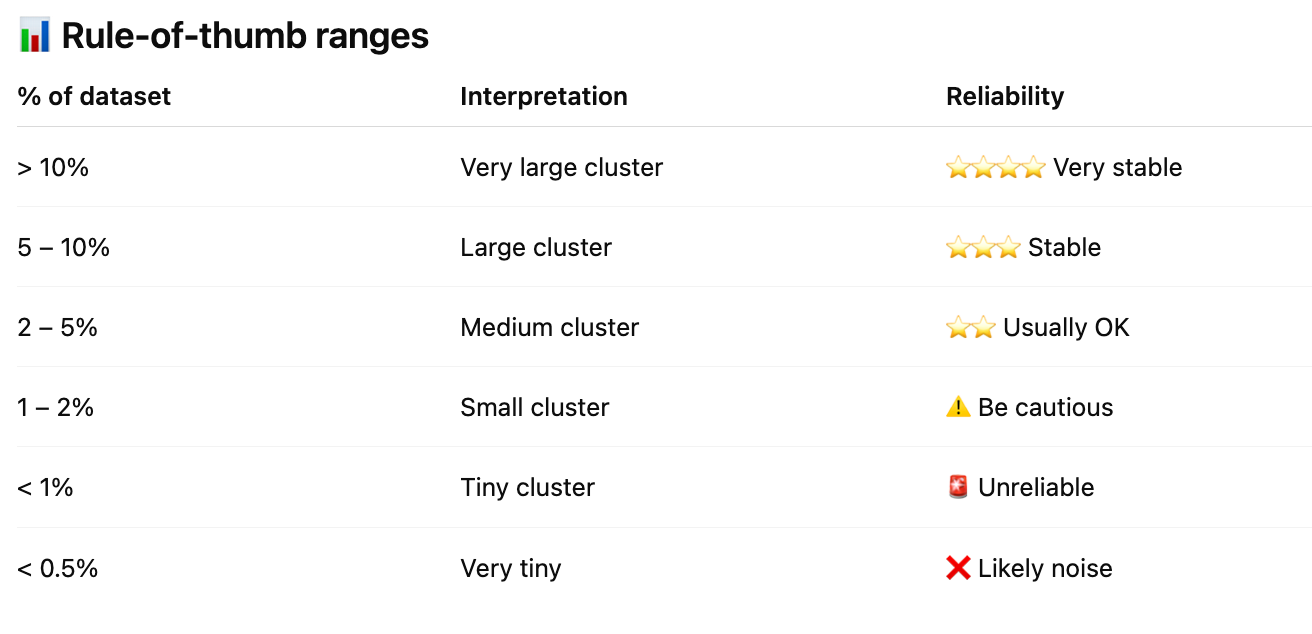